In [1]:
import pandas as pd
import os
os.chdir("/Users/alyshoukry/Desktop/MSc/Dissertation/adaptive-pv-forecasting")
df_london = pd.read_csv("data/raw/pvgis_london.csv",
skiprows=10,
skipfooter=6,
header=0,
engine="python"
)

print(df_london.head())
(df_london.tail(20))

            time    P  Gb(i)  Gd(i)  Gr(i)  H_sun   T2m  WS10m  Int
0  20150101:0010  0.0    0.0    0.0    0.0    0.0  4.61   4.14  0.0
1  20150101:0110  0.0    0.0    0.0    0.0    0.0  4.85   4.14  0.0
2  20150101:0210  0.0    0.0    0.0    0.0    0.0  5.23   4.21  0.0
3  20150101:0310  0.0    0.0    0.0    0.0    0.0  5.58   4.41  0.0
4  20150101:0410  0.0    0.0    0.0    0.0    0.0  5.94   4.55  0.0


,time,P,Gb(i),Gd(i),Gr(i),H_sun,T2m,WS10m,Int
78874,20231231:1010,149.93,84.13,98.18,2.01,11.43,7.41,5.93,0.0
78875,20231231:1110,320.89,223.71,144.74,3.26,14.52,7.90,6.48,0.0
78876,20231231:1210,210.84,113.25,135.86,2.88,15.38,8.39,5.59,0.0
78877,20231231:1310,174.82,91.28,118.82,2.48,13.92,8.70,6.14,0.0
78878,20231231:1410,85.37,39.19,73.21,1.48,10.30,8.81,6.55,0.0
78879,20231231:1510,18.90,11.70,23.24,0.47,4.81,8.53,6.41,0.0
78880,20231231:1610,0.00,0.00,0.00,0.00,0.00,8.18,6.00,0.0
78881,20231231:1710,0.00,0.00,0.00,0.00,0.00,7.94,6.21,0.0
78882,20231231:1810,0.00,0.00,0.00,0.00,0.00,7.75,6.55,0.0
78883,20231231:1910,0.00,0.00,0.00,0.00,0.00,7.24,6.69,0.0


In [2]:

df_london = df_london[df_london["time"].str.match(r"^\d{8}:\d{4}$", na=False)]
df_london["time"] = pd.to_datetime(df_london["time"], format="%Y%m%d:%H%M")
df_london = df_london.dropna(subset=["P"])

df_london["P"] = pd.to_numeric(df_london["P"], errors="coerce")

print(df_london.head())
df_london = df_london.drop(columns=["Int"])

print(df_london.describe())

                 time    P  Gb(i)  Gd(i)  Gr(i)  H_sun   T2m  WS10m  Int
0 2015-01-01 00:10:00  0.0    0.0    0.0    0.0    0.0  4.61   4.14  0.0
1 2015-01-01 01:10:00  0.0    0.0    0.0    0.0    0.0  4.85   4.14  0.0
2 2015-01-01 02:10:00  0.0    0.0    0.0    0.0    0.0  5.23   4.21  0.0
3 2015-01-01 03:10:00  0.0    0.0    0.0    0.0    0.0  5.58   4.41  0.0
4 2015-01-01 04:10:00  0.0    0.0    0.0    0.0    0.0  5.94   4.55  0.0
                      time             P         Gb(i)         Gd(i)  \
count                78888  78888.000000  78888.000000  78888.000000   
mean   2019-07-02 11:40:00    116.186761     76.945622     67.322323   
min    2015-01-01 00:10:00      0.000000      0.000000      0.000000   
25%    2017-04-01 17:55:00      0.000000      0.000000      0.000000   
50%    2019-07-02 11:40:00      0.000000      0.000000      0.000000   
75%    2021-10-01 05:25:00    149.725000     34.910000    119.570000   
max    2023-12-31 23:10:00    889.270000    963.560000    

In [3]:
print(df_london.isna().sum())
print(df_london.duplicated(subset=["time"]).sum())
df_london = df_london.set_index("time").sort_index()
expected = pd.date_range(df_london.index.min(), df_london.index.max(), freq="1h")
missing = expected.difference(df_london.index)
print(f"Missing timestamps: {len(missing)}")
print((df_london[["P", "Gb(i)", "Gd(i)", "Gr(i)"]] < 0).sum())
print(df_london.head(-1))

time     0
P        0
Gb(i)    0
Gd(i)    0
Gr(i)    0
H_sun    0
T2m      0
WS10m    0
dtype: int64
0
Missing timestamps: 0
P        0
Gb(i)    0
Gd(i)    0
Gr(i)    0
dtype: int64
                       P  Gb(i)  Gd(i)  Gr(i)  H_sun   T2m  WS10m
time                                                             
2015-01-01 00:10:00  0.0    0.0    0.0    0.0    0.0  4.61   4.14
2015-01-01 01:10:00  0.0    0.0    0.0    0.0    0.0  4.85   4.14
2015-01-01 02:10:00  0.0    0.0    0.0    0.0    0.0  5.23   4.21
2015-01-01 03:10:00  0.0    0.0    0.0    0.0    0.0  5.58   4.41
2015-01-01 04:10:00  0.0    0.0    0.0    0.0    0.0  5.94   4.55
...                  ...    ...    ...    ...    ...   ...    ...
2023-12-31 18:10:00  0.0    0.0    0.0    0.0    0.0  7.75   6.55
2023-12-31 19:10:00  0.0    0.0    0.0    0.0    0.0  7.24   6.69
2023-12-31 20:10:00  0.0    0.0    0.0    0.0    0.0  7.06   6.83
2023-12-31 21:10:00  0.0    0.0    0.0    0.0    0.0  7.25   6.97
2023-12-31 22:10:00  0.0  

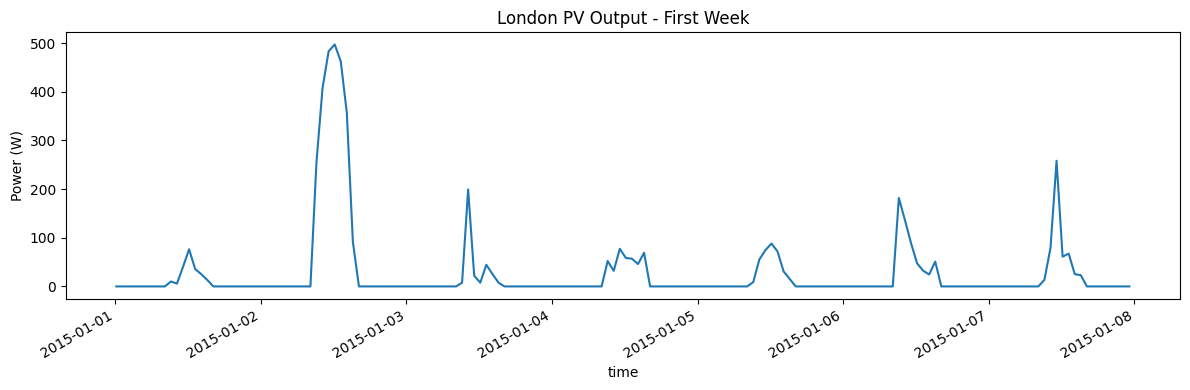

In [ ]:
import matplotlib.pyplot as plt

#plot a week of power output
df_london["P"].iloc[:168].plot(figsize=(12, 4), title="London PV Output - First Week")
plt.ylabel("Power (W)")
plt.tight_layout()
plt.show()

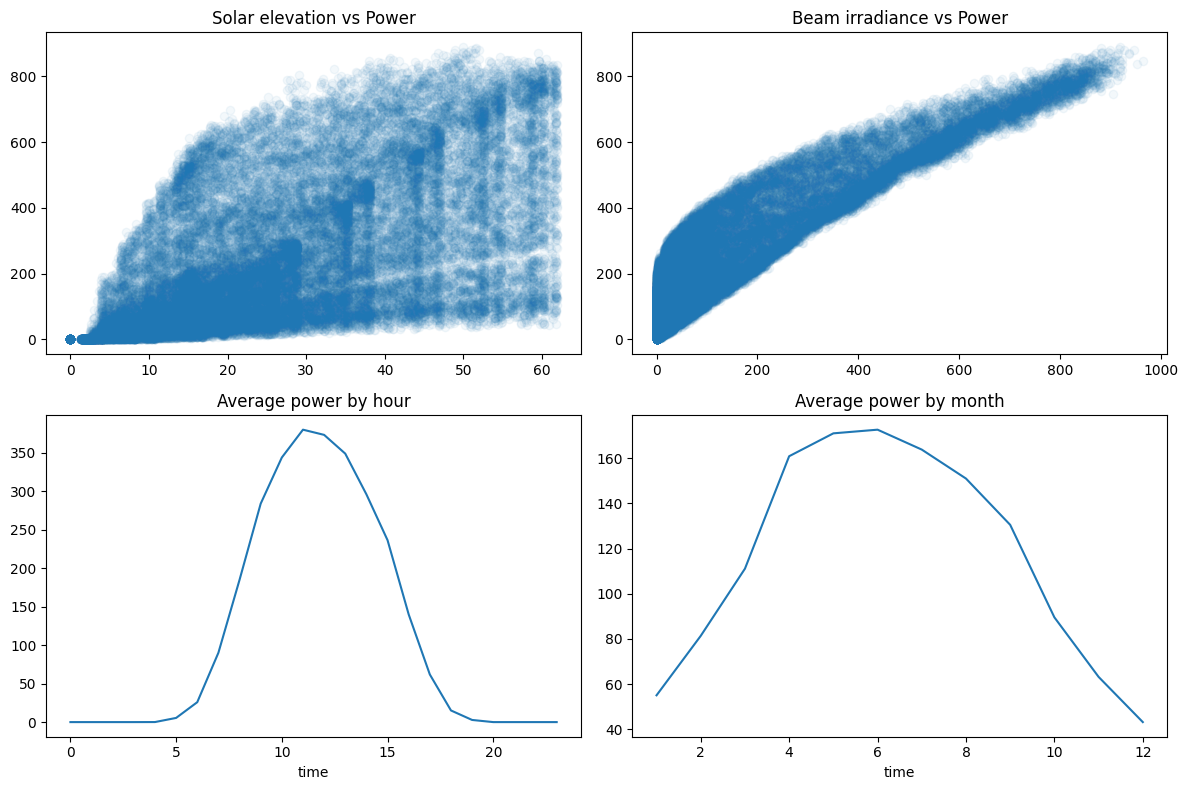

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. H_sun vs P — should be strong positive correlation
axes[0,0].scatter(df_london["H_sun"], df_london["P"], alpha=0.05)
axes[0,0].set_title("Solar elevation vs Power")

# 2. Gb(i) vs P — should be strongest correlation
axes[0,1].scatter(df_london["Gb(i)"], df_london["P"], alpha=0.05)
axes[0,1].set_title("Beam irradiance vs Power")

# 3. Average by hour
df_london.reset_index(inplace=True)
df_london.groupby(df_london["time"].dt.hour)["P"].mean().plot(ax=axes[1,0])
axes[1,0].set_title("Average power by hour")

# 4. Average by month
df_london.groupby(df_london["time"].dt.month)["P"].mean().plot(ax=axes[1,1])
axes[1,1].set_title("Average power by month")

plt.tight_layout()
plt.show()

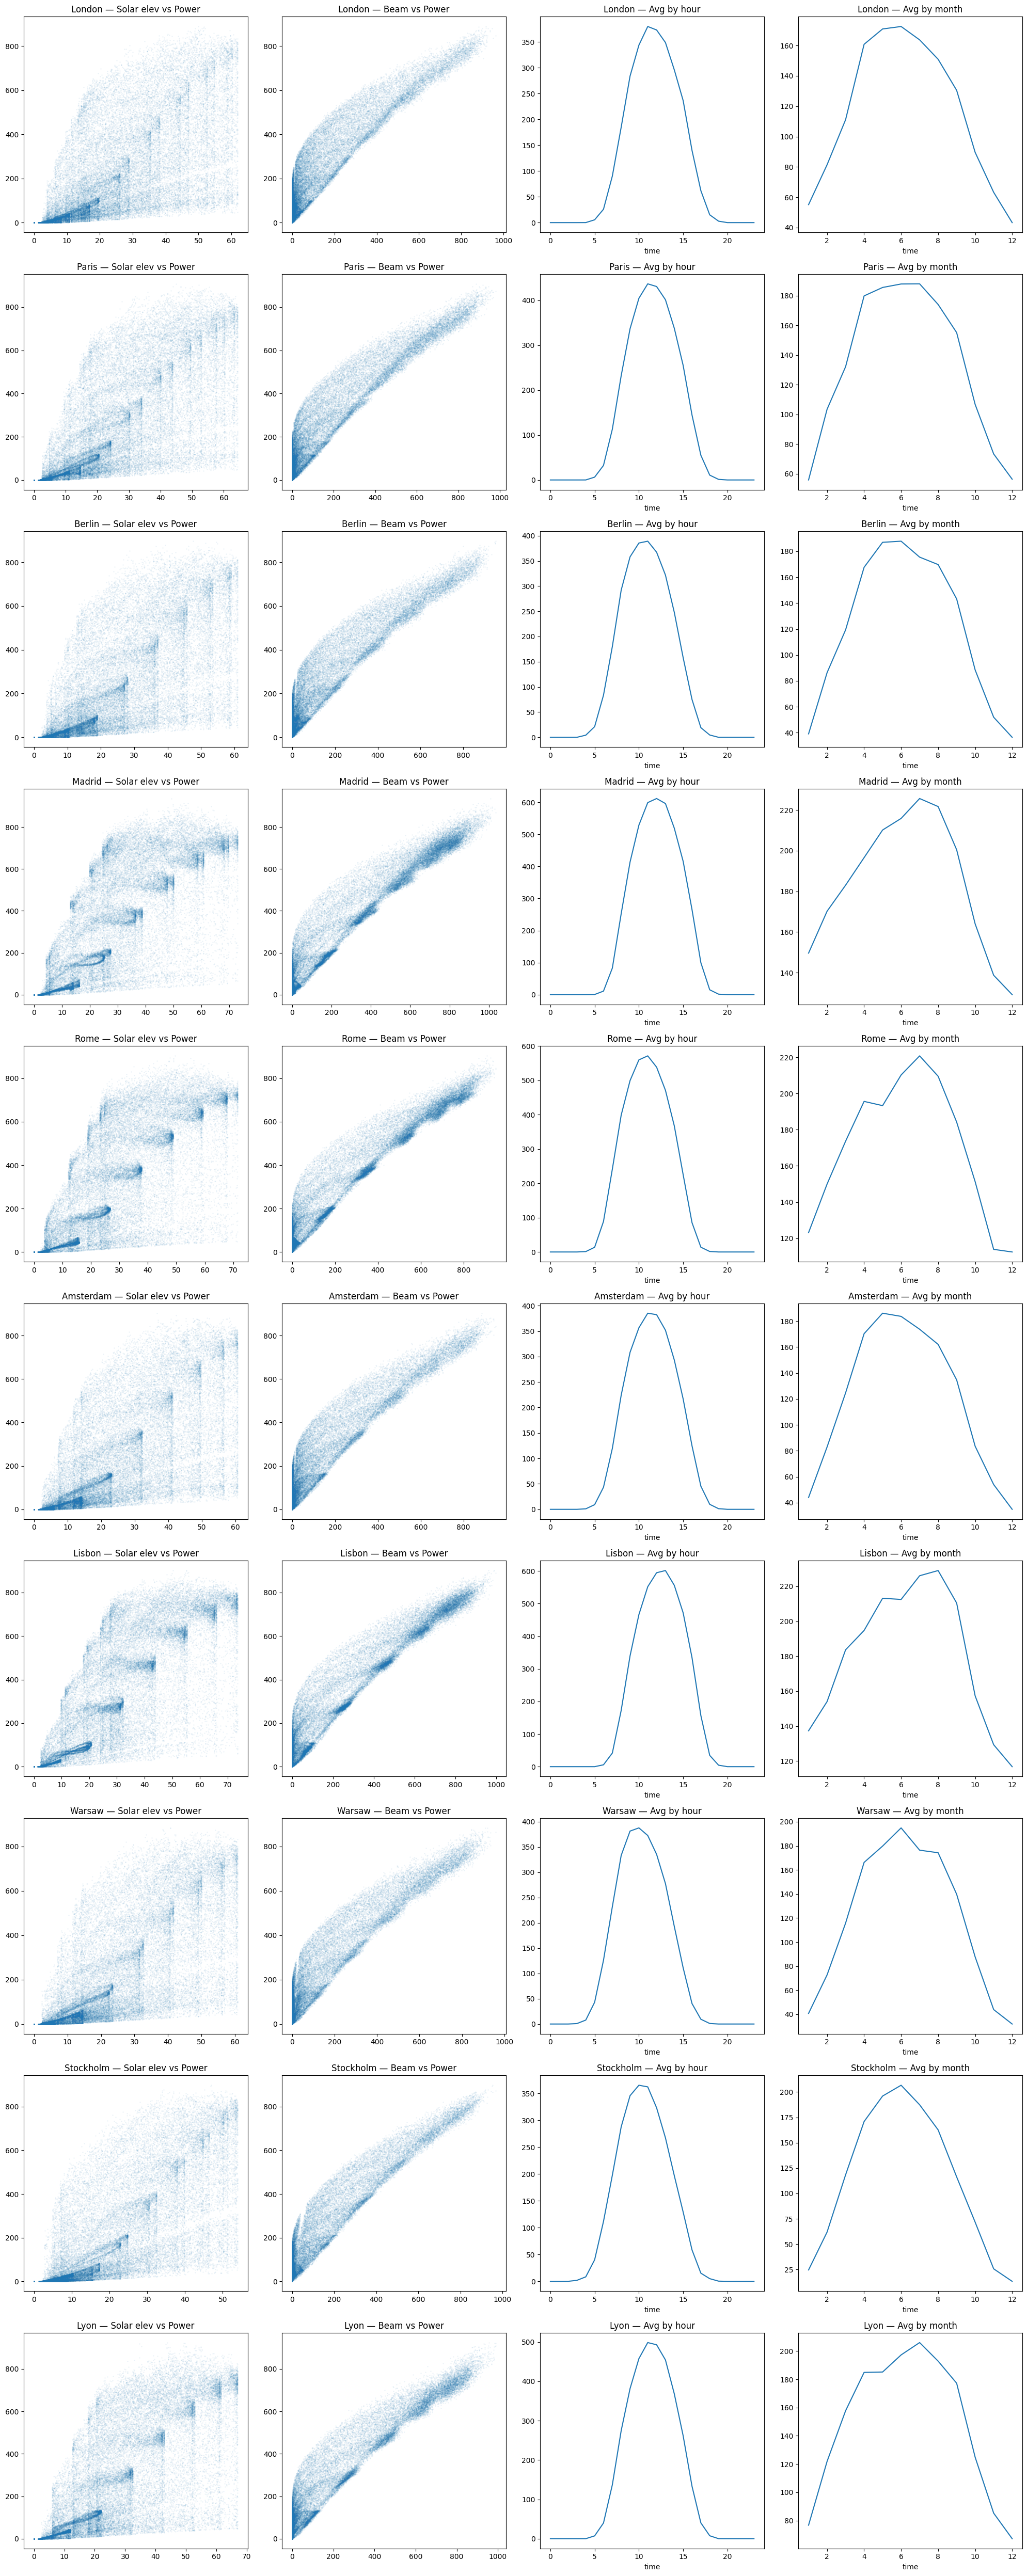

In [14]:
locations = ["london", "paris", "berlin", "madrid", "rome",
             "amsterdam", "lisbon", "warsaw", "stockholm", "lyon"]

fig, axes = plt.subplots(10, 4, figsize=(20, 50))

for i, loc in enumerate(locations):
    df = pd.read_csv(f"data/raw/pvgis_{loc}.csv", skiprows=10, 
                     header=0, low_memory=False)
    df = df.dropna(subset=["P"])
    df["P"] = pd.to_numeric(df["P"], errors="coerce")
    df = df[df["time"].str.match(r"^\d{8}:\d{4}$", na=False)]
    df["time"] = pd.to_datetime(df["time"], format="%Y%m%d:%H%M")
    df = df.drop(columns=["Int"])

    # solar elevation vs power
    axes[i,0].scatter(df["H_sun"], df["P"], alpha=0.05, s=1)
    axes[i,0].set_title(f"{loc.capitalize()} — Solar elev vs Power")

    # beam irradiance vs power
    axes[i,1].scatter(df["Gb(i)"], df["P"], alpha=0.05, s=1)
    axes[i,1].set_title(f"{loc.capitalize()} — Beam vs Power")

    # average by hour
    df.groupby(df["time"].dt.hour)["P"].mean().plot(ax=axes[i,2])
    axes[i,2].set_title(f"{loc.capitalize()} — Avg by hour")

    # average by month
    df.groupby(df["time"].dt.month)["P"].mean().plot(ax=axes[i,3])
    axes[i,3].set_title(f"{loc.capitalize()} — Avg by month")

plt.tight_layout()
plt.savefig("results/eda_all_locations.png", dpi=150)
plt.show()